In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [4]:
df = df.dropna()
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [5]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [6]:
df.shape

(20433, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [10]:
df["median_house_value"].value_counts()

median_house_value
500001.0    958
137500.0    119
162500.0    116
112500.0    103
187500.0     92
           ... 
359200.0      1
51200.0       1
39800.0       1
377600.0      1
47000.0       1
Name: count, Length: 3833, dtype: int64

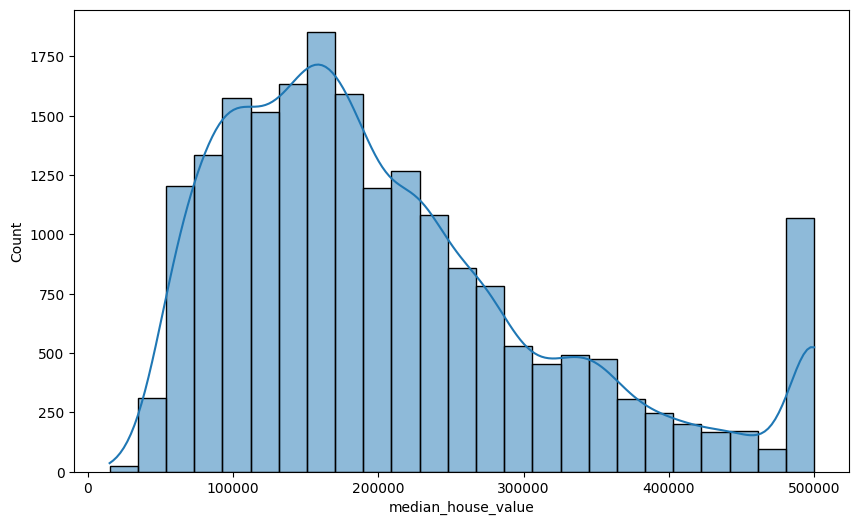

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=25, kde=True)
plt.show()

In [12]:
df = df[df['median_house_value'] < 499999.0]

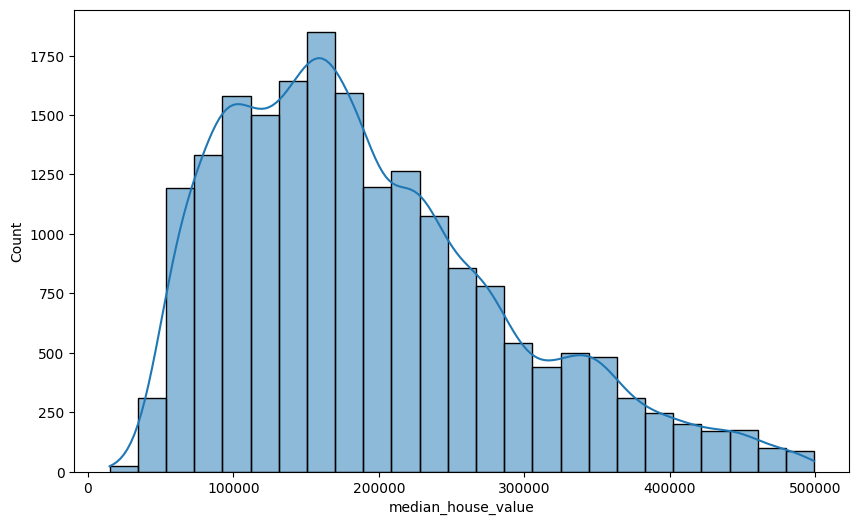

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=25, kde=True)
plt.show()

In [14]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")

encoded_array = ohe.fit_transform(df[["ocean_proximity"]])

feature_names = ohe.get_feature_names_out()

df_ohe_columns = pd.DataFrame(encoded_array, columns=feature_names)

df_ohe_columns.head()

,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


In [15]:
df_final = pd.concat([df_ohe_columns.reset_index(), df.reset_index()], axis=1)
df_final = df_final.drop("ocean_proximity", axis=1)
df_final.head()

,index,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0,0.0,0.0,1.0,0.0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,1,0.0,0.0,1.0,0.0,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,2,0.0,0.0,1.0,0.0,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,3,0.0,0.0,1.0,0.0,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,4,0.0,0.0,1.0,0.0,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [16]:
df_final.shape

(19448, 15)

In [17]:
df_final.dropna()


,index,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0,0.0,0.0,1.0,0.0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,1,0.0,0.0,1.0,0.0,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,2,0.0,0.0,1.0,0.0,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,3,0.0,0.0,1.0,0.0,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,4,0.0,0.0,1.0,0.0,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19443,19443,1.0,0.0,0.0,0.0,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
19444,19444,1.0,0.0,0.0,0.0,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
19445,19445,1.0,0.0,0.0,0.0,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
19446,19446,1.0,0.0,0.0,0.0,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [18]:
X = df_final.drop("median_house_value", axis = 1)
Y = df_final["median_house_value"]

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state = 42)

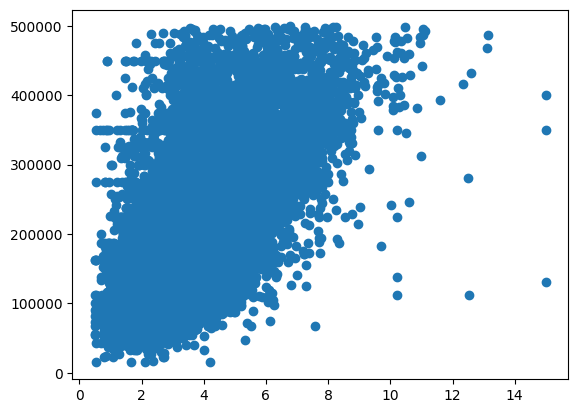

In [20]:
plt.scatter(df["median_income"], df["median_house_value"])

In [21]:
lr = LinearRegression()

In [22]:
lr_model = lr.fit(X_train, Y_train)

In [23]:
training_score = lr.score(X_train, Y_train)
print(f"Coefficient of determination (R-squared): {training_score}")
print(f"Intercept: {lr.intercept_}")
print(f"Slope (Coefficient): {lr.coef_}")

Coefficient of determination (R-squared): 0.6168977501120565
Intercept: -1936388.152040449
Slope (Coefficient): [-4.56162062e+01 -3.87802902e+04  2.10013516e+05 -5.09508825e+03
  4.10425142e+03  4.33895076e+01 -2.27784952e+04 -2.14519446e+04
  1.01033313e+03 -8.43566882e+00  9.77490965e+01 -2.82286442e+01
  3.85860080e+01  3.86756632e+04]


In [24]:
y_pred = lr.predict(X_test)


In [25]:
r2_squared_score = r2_score(Y_test, y_pred)

In [26]:
print(f"Actual values:   {Y_test}")
print(f"Predicted values: {y_pred}")
print(f"R-squared score:  {r2_squared_score}")

Actual values:   8962      73800.0
19059    359100.0
8950      94700.0
4115     238200.0
18842     49000.0
           ...   
6266     163100.0
19399     55500.0
5846     140600.0
14128     96200.0
3646     187500.0
Name: median_house_value, Length: 5835, dtype: float64
Predicted values: [106844.7179823  270650.29220783 137484.90931121 ... 145835.03885487
 132223.10069368 147048.21027721]
R-squared score:  0.621918299444965


In [27]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# L1 Regularization (Lasso)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, Y_train)
y_pred_lasso = lasso.predict(X_test)

# L2 Regularization (Ridge)
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, Y_train)
y_pred_ridge = ridge.predict(X_test)

# Elastic Net Regularization
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, Y_train)
y_pred_elastic = elastic.predict(X_test)

print("Lasso R2 Score:", r2_score(Y_test, y_pred_lasso))
print("Ridge R2 Score:", r2_score(Y_test, y_pred_ridge))
print("ElasticNet R2 Score:", r2_score(Y_test, y_pred_elastic))

c:\Users\shrey\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.444e+13, tolerance: 1.275e+10
  model = cd_fast.enet_coordinate_descent(


Lasso R2 Score: 0.6215942044082836
Ridge R2 Score: 0.6219876840765519
ElasticNet R2 Score: 0.6192271448232627


c:\Users\shrey\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.573e+13, tolerance: 1.275e+10
  model = cd_fast.enet_coordinate_descent(
